In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


In [29]:
df = pd.read_csv('/Users/anthonyjaramillo/PycharmProjects/4900/data/processed/model_features_v2.csv')

print(f"Shape: {df.shape}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Cover rate: {df['covered'].mean():.3f}")

FEATURE_COLS = (
    [col for col in df.columns if col.startswith(('home_avg', 'away_avg'))] +
    ['spread_line', 'is_primetime', 'div_game', 'is_dome', 'is_grass',
     'temp', 'wind', 'home_rest', 'away_rest',
     'home_skill_injuries', 'away_skill_injuries', 'home_qb_out', 'away_qb_out']
)

X = df[FEATURE_COLS]
y = df['covered']

train_mask = df['season'] <= 2022
test_mask  = df['season'].isin([2023, 2024])

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTraining samples : {len(X_train)} ({sorted(df[train_mask]['season'].unique())})")
print(f"Testing samples  : {len(X_test)}  ({sorted(df[test_mask]['season'].unique())})")
print(f"Features         : {len(FEATURE_COLS)}")


Shape: (2648, 36)
Seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Cover rate: 0.511

Training samples : 1899 ([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])
Testing samples  : 494  ([2023, 2024])
Features         : 29


── Logistic Regression ──────────────────────
Accuracy : 0.5182
ROC AUC  : 0.5115

              precision    recall  f1-score   support

 Not Covered       0.53      0.56      0.54       252
     Covered       0.51      0.48      0.49       242

    accuracy                           0.52       494
   macro avg       0.52      0.52      0.52       494
weighted avg       0.52      0.52      0.52       494



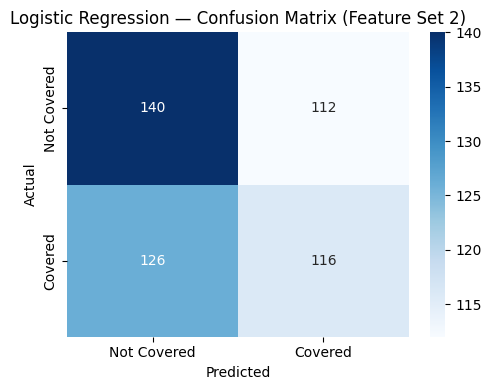

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print("── Logistic Regression ──────────────────────")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"\n{classification_report(y_test, lr_preds, target_names=['Not Covered', 'Covered'])}")

cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Covered', 'Covered'],
            yticklabels=['Not Covered', 'Covered'])
plt.title('Logistic Regression — Confusion Matrix (Feature Set 2)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


── Random Forest ────────────────────────────
Accuracy : 0.5101
ROC AUC  : 0.5222

              precision    recall  f1-score   support

 Not Covered       0.52      0.49      0.50       252
     Covered       0.50      0.53      0.52       242

    accuracy                           0.51       494
   macro avg       0.51      0.51      0.51       494
weighted avg       0.51      0.51      0.51       494



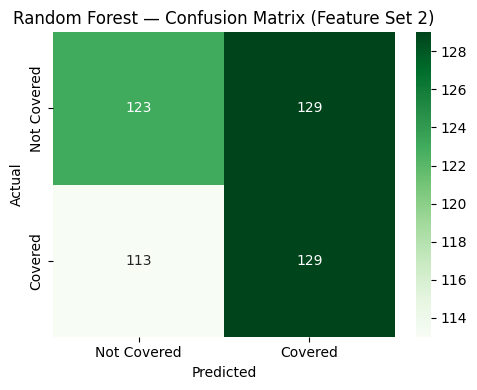

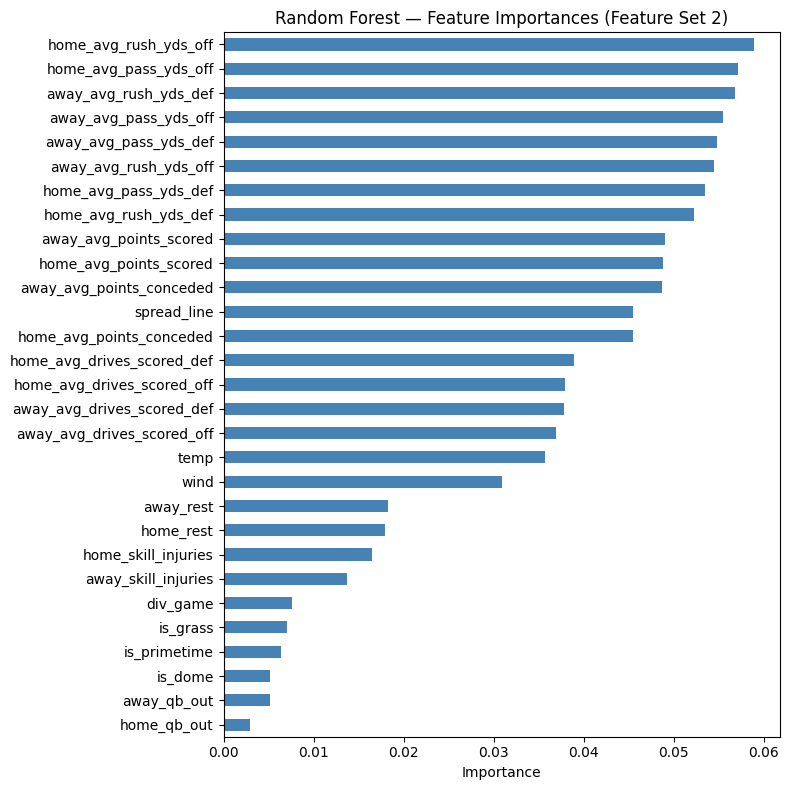

In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("── Random Forest ────────────────────────────")
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"\n{classification_report(y_test, rf_preds, target_names=['Not Covered', 'Covered'])}")

cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Covered', 'Covered'],
            yticklabels=['Not Covered', 'Covered'])
plt.title('Random Forest — Confusion Matrix (Feature Set 2)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(8, 8))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importances (Feature Set 2)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


── XGBoost ──────────────────────────────────
Accuracy : 0.4838
ROC AUC  : 0.4711

              precision    recall  f1-score   support

 Not Covered       0.49      0.51      0.50       252
     Covered       0.47      0.46      0.47       242

    accuracy                           0.48       494
   macro avg       0.48      0.48      0.48       494
weighted avg       0.48      0.48      0.48       494



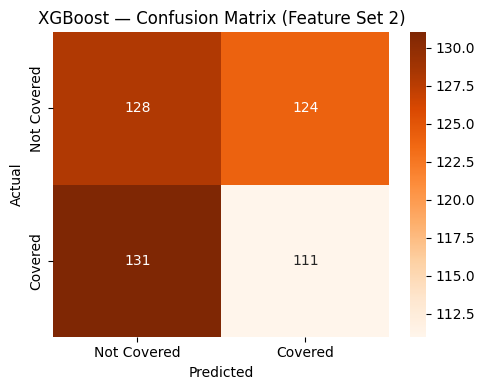

In [32]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print("── XGBoost ──────────────────────────────────")
print(f"Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"\n{classification_report(y_test, xgb_preds, target_names=['Not Covered', 'Covered'])}")

cm_xgb = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Covered', 'Covered'],
            yticklabels=['Not Covered', 'Covered'])
plt.title('XGBoost — Confusion Matrix (Feature Set 2)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [33]:
FEATURE_COLS_NO_SPREAD = [col for col in FEATURE_COLS if col != 'spread_line']

X_train_ns = X_train[FEATURE_COLS_NO_SPREAD]
X_test_ns  = X_test[FEATURE_COLS_NO_SPREAD]

# Logistic Regression
scaler2 = StandardScaler()
X_train_ns_scaled = scaler2.fit_transform(X_train_ns)
X_test_ns_scaled  = scaler2.transform(X_test_ns)

lr_ns = LogisticRegression(max_iter=1000, random_state=42)
lr_ns.fit(X_train_ns_scaled, y_train)
lr_ns_probs = lr_ns.predict_proba(X_test_ns_scaled)[:, 1]

# Random Forest
rf_ns = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ns.fit(X_train_ns, y_train)
rf_ns_probs = rf_ns.predict_proba(X_test_ns)[:, 1]

# XGBoost
xgb_ns = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb_ns.fit(X_train_ns, y_train)
xgb_ns_probs = xgb_ns.predict_proba(X_test_ns)[:, 1]

print("WITH spread_line:")
print(f"  LR  AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"  RF  AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(f"  XGB AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

print("\nWITHOUT spread_line:")
print(f"  LR  AUC: {roc_auc_score(y_test, lr_ns_probs):.4f}")
print(f"  RF  AUC: {roc_auc_score(y_test, rf_ns_probs):.4f}")
print(f"  XGB AUC: {roc_auc_score(y_test, xgb_ns_probs):.4f}")

print(f"\nBaseline (majority class): {max(y_test.mean(), 1 - y_test.mean()):.4f}")


WITH spread_line:
  LR  AUC: 0.5115
  RF  AUC: 0.5222
  XGB AUC: 0.4711

WITHOUT spread_line:
  LR  AUC: 0.5110
  RF  AUC: 0.4939
  XGB AUC: 0.5096

Baseline (majority class): 0.5101


In [34]:
mask_2025 = df['season'] == 2025
X_2025 = X[mask_2025]
y_2025 = y[mask_2025]

X_2025_scaled = scaler.transform(X_2025)

lr_2025_probs  = lr.predict_proba(X_2025_scaled)[:, 1]
rf_2025_probs  = rf.predict_proba(X_2025)[:, 1]
xgb_2025_probs = xgb.predict_proba(X_2025)[:, 1]

lr_2025_preds  = lr.predict(X_2025_scaled)
rf_2025_preds  = rf.predict(X_2025)
xgb_2025_preds = xgb.predict(X_2025)

print("── 2025 Season Holdout ──────────────────────")
print(f"LR  — Accuracy: {accuracy_score(y_2025, lr_2025_preds):.4f}  AUC: {roc_auc_score(y_2025, lr_2025_probs):.4f}")
print(f"RF  — Accuracy: {accuracy_score(y_2025, rf_2025_preds):.4f}  AUC: {roc_auc_score(y_2025, rf_2025_probs):.4f}")
print(f"XGB — Accuracy: {accuracy_score(y_2025, xgb_2025_preds):.4f}  AUC: {roc_auc_score(y_2025, xgb_2025_probs):.4f}")


── 2025 Season Holdout ──────────────────────
LR  — Accuracy: 0.4784  AUC: 0.4956
RF  — Accuracy: 0.5412  AUC: 0.5475
XGB — Accuracy: 0.5373  AUC: 0.5503


In [40]:

df = pd.read_csv('/Users/anthonyjaramillo/PycharmProjects/4900/data/processed/model_features_v2.csv')
schedules = pd.read_csv('/Users/anthonyjaramillo/PycharmProjects/4900/data/raw/schedules_2015_2025.csv')

check = df[['game_id', 'home_team', 'away_team', 'spread_line', 'covered']].merge(
    schedules[['game_id', 'home_score', 'away_score', 'result']],
    on='game_id'
).head(20)

print(check.to_string())


            game_id home_team away_team  spread_line  covered  home_score  away_score  result
0   2015_02_ARI_CHI       CHI       ARI         -2.0        1          23          48     -25
1   2015_02_ATL_NYG       NYG       ATL          2.0        1          20          24      -4
2   2015_02_BAL_OAK        LV       BAL         -6.0        0          37          33       4
3   2015_02_DAL_PHI       PHI       DAL          7.0        1          10          20     -10
4    2015_02_DEN_KC        KC       DEN          3.0        1          24          31      -7
5   2015_02_DET_MIN       MIN       DET          2.5        0          26          16      10
6   2015_02_HOU_CAR       CAR       HOU          3.0        0          24          17       7
7   2015_02_MIA_JAX       JAX       MIA         -5.0        0          23          20       3
8    2015_02_NE_BUF       BUF        NE          2.0        1          32          40      -8
9   2015_02_NYJ_IND       IND       NYJ          6.0        

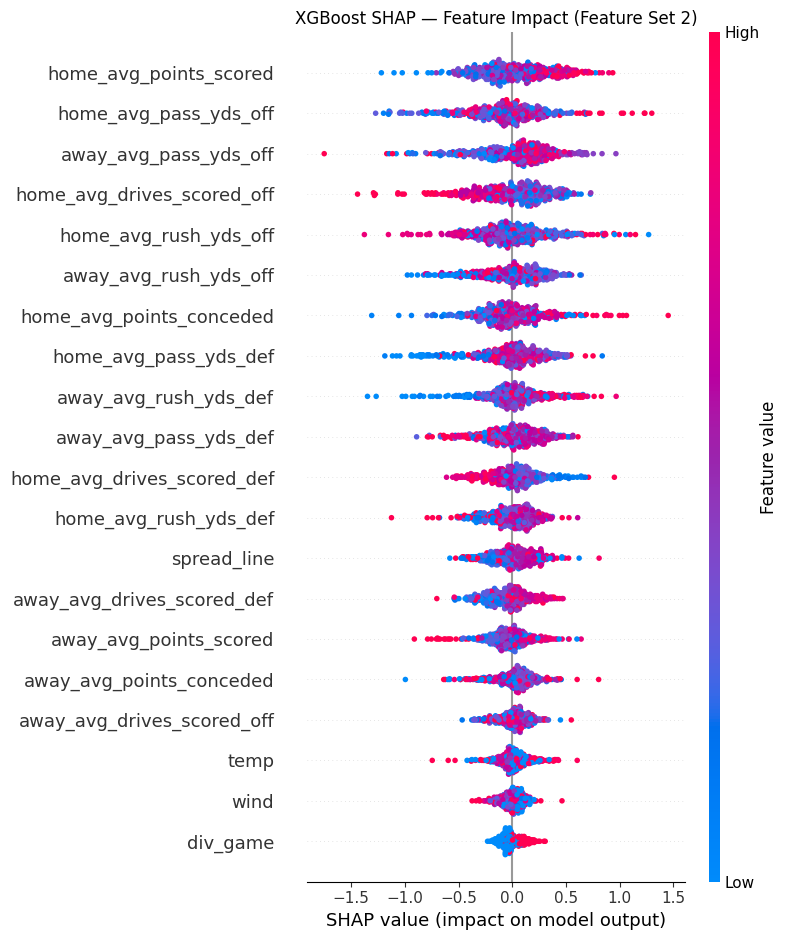

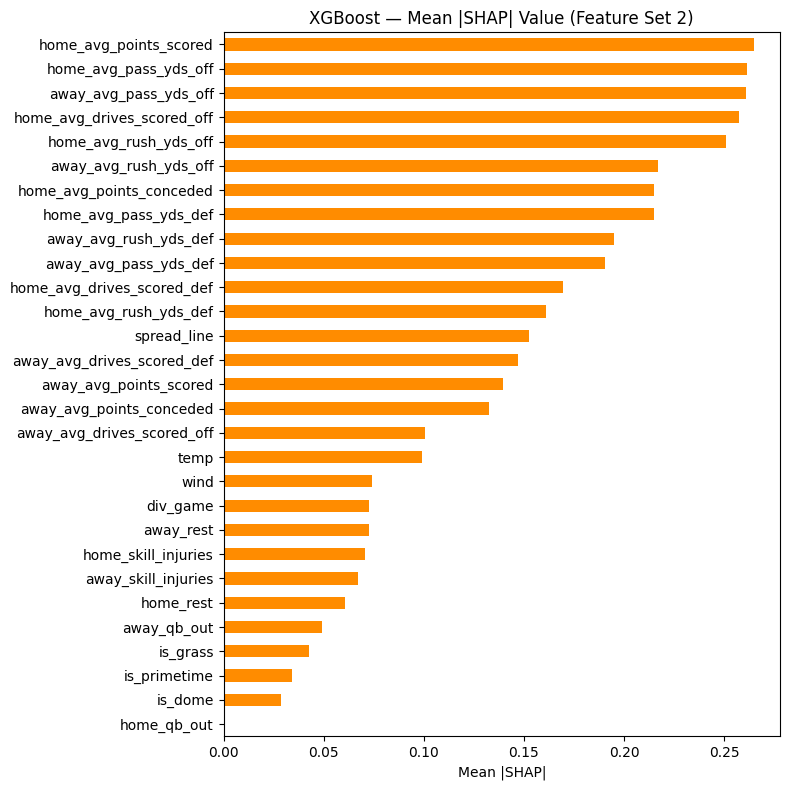

In [41]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('XGBoost SHAP — Feature Impact (Feature Set 2)')
plt.tight_layout()
plt.show()

# Mean absolute SHAP values (overall importance ranking)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
shap_importance.plot(kind='barh', color='darkorange')
plt.title('XGBoost — Mean |SHAP| Value (Feature Set 2)')
plt.xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()


In [42]:
import pandas as pd

schedules_raw = pd.read_csv('/Users/anthonyjaramillo/PycharmProjects/4900/data/raw/schedules_2015_2025.csv')

# Build results dataframe for test set
results = df[test_mask][['game_id', 'season', 'week', 'gameday', 'home_team', 'away_team', 'spread_line', 'covered']].copy()
results['predicted_cover'] = lr_preds
results['correct'] = (results['predicted_cover'] == results['covered']).astype(int)

# Merge in scores and odds from schedules
results = results.merge(
    schedules_raw[['game_id', 'home_score', 'away_score', 'home_spread_odds', 'away_spread_odds']],
    on='game_id', how='left'
)

# Rename for clarity
results = results.rename(columns={
    'covered': 'actual_cover',
    'home_spread_odds': 'home_odds',
    'away_spread_odds': 'away_odds'
})

# Reorder columns
results = results[[
    'game_id', 'gameday', 'home_team', 'away_team',
    'home_score', 'away_score', 'spread_line',
    'home_odds', 'away_odds',
    'predicted_cover', 'actual_cover', 'correct'
]]

pd.set_option('display.max_rows', 100)
print(f"Total games: {len(results)}")
print(f"Correct predictions: {results['correct'].sum()} ({results['correct'].mean():.3f})")
print()
print(results.to_string(index=False))


Total games: 494
Correct predictions: 256 (0.518)

        game_id    gameday home_team away_team  home_score  away_score  spread_line  home_odds  away_odds  predicted_cover  actual_cover  correct
2023_02_BAL_CIN 2023-09-17       CIN       BAL          24          27          3.5     -102.0     -118.0                0             1        0
 2023_02_CHI_TB 2023-09-17        TB       CHI          27          17          2.5     -110.0     -110.0                0             0        1
2023_02_CLE_PIT 2023-09-18       PIT       CLE          26          22         -2.5     -105.0     -115.0                0             0        1
 2023_02_GB_ATL 2023-09-17       ATL        GB          25          24          3.0     -105.0     -115.0                0             1        0
2023_02_IND_HOU 2023-09-17       HOU       IND          20          31         -1.0     -115.0     -105.0                0             1        0
 2023_02_KC_JAX 2023-09-17       JAX        KC           9          17   

In [43]:
# Filter out division games from test set
non_div_mask = df[test_mask]['div_game'] == 0

X_test_nd   = X_test[non_div_mask]
y_test_nd   = y_test[non_div_mask]

X_test_nd_scaled = scaler.transform(X_test_nd)

# Predictions on non-division games only
lr_nd_preds  = lr.predict(X_test_nd_scaled)
rf_nd_preds  = rf.predict(X_test_nd)
xgb_nd_preds = xgb.predict(X_test_nd)

print(f"Total test games       : {len(y_test)}")
print(f"Non-division games     : {len(y_test_nd)}")
print(f"Division games removed : {len(y_test) - len(y_test_nd)}")
print()
print("── Accuracy on non-division games only ──────────")
print(f"LR  : {accuracy_score(y_test_nd, lr_nd_preds):.4f}")
print(f"RF  : {accuracy_score(y_test_nd, rf_nd_preds):.4f}")
print(f"XGB : {accuracy_score(y_test_nd, xgb_nd_preds):.4f}")
print(f"\nBaseline : {max(y_test_nd.mean(), 1 - y_test_nd.mean()):.4f}")
print()

# Comparison table
comparison = pd.DataFrame({
    'Model': ['LR', 'RF', 'XGB'],
    'All games': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'Non-div only': [
        accuracy_score(y_test_nd, lr_nd_preds),
        accuracy_score(y_test_nd, rf_nd_preds),
        accuracy_score(y_test_nd, xgb_nd_preds)
    ]
}).round(4)

print(comparison.to_string(index=False))


Total test games       : 494
Non-division games     : 318
Division games removed : 176

── Accuracy on non-division games only ──────────
LR  : 0.5472
RF  : 0.5031
XGB : 0.5000

Baseline : 0.5283

Model  All games  Non-div only
   LR     0.5182        0.5472
   RF     0.5101        0.5031
  XGB     0.4838        0.5000


In [51]:
# Train and test on non-division games only
train_mask_nd = (df['season'] <= 2022) & (df['div_game'] == 0)
test_mask_nd  = df['season'].isin([2023, 2024]) & (df['div_game'] == 0)
val_mask_nd   = (df['season'] == 2025) & (df['div_game'] == 0)

X_tr_nd, y_tr_nd   = X[train_mask_nd], y[train_mask_nd]
X_te_nd, y_te_nd   = X[test_mask_nd],  y[test_mask_nd]
X_val_nd, y_val_nd = X[val_mask_nd],   y[val_mask_nd]

# Scale
scaler_nd       = StandardScaler()
X_tr_nd_scaled  = scaler_nd.fit_transform(X_tr_nd)
X_te_nd_scaled  = scaler_nd.transform(X_te_nd)
X_val_nd_scaled = scaler_nd.transform(X_val_nd)

# Train
lr_nd  = LogisticRegression(max_iter=1000, random_state=42)
rf_nd  = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_nd = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)

lr_nd.fit(X_tr_nd_scaled, y_tr_nd)
rf_nd.fit(X_tr_nd, y_tr_nd)
xgb_nd.fit(X_tr_nd, y_tr_nd)

print(f"Training games (non-div, 2015-2022) : {len(y_tr_nd)}")
print(f"Test games     (non-div, 2023-2024) : {len(y_te_nd)}")
print(f"Val games      (non-div, 2025)      : {len(y_val_nd)}")

# ── Evaluate and simulate ────────────────────────────────────────────────────
def betting_sim(game_df, pred_col, actual_col='actual', stake=100):
    profits = []
    for _, row in game_df.iterrows():
        odds   = row['away_spread_odds'] if row[pred_col] == 1 else row['home_spread_odds']
        profit = american_odds_profit(odds, stake) if row[pred_col] == row[actual_col] else -stake
        profits.append(profit)
    total_profit  = sum(profits)
    roi           = (total_profit / (len(profits) * stake)) * 100
    win_rate      = sum(p > 0 for p in profits) / len(profits)
    return total_profit, roi, win_rate

for split_label, game_df_base, preds_dict in [
    ('Test  (2023-2024)', df[test_mask_nd].copy(), {
        'LR' : lr_nd.predict(X_te_nd_scaled),
        'RF' : rf_nd.predict(X_te_nd),
        'XGB': xgb_nd.predict(X_te_nd)
    }),
    ('Val   (2025)',      df[val_mask_nd].copy(), {
        'LR' : lr_nd.predict(X_val_nd_scaled),
        'RF' : rf_nd.predict(X_val_nd),
        'XGB': xgb_nd.predict(X_val_nd)
    })
]:
    game_df_base = game_df_base.merge(
        schedules_raw[['game_id', 'home_spread_odds', 'away_spread_odds']],
        on='game_id', how='left'
    )
    game_df_base['actual'] = game_df_base['covered'].values

    print(f"\n── {split_label} ─────────────────────────────────────────")
    print(f"{'Model':<6} {'Accuracy':>10} {'Profit':>12} {'ROI':>8} {'Win Rate':>10}")
    print("-" * 50)

    for model_name, preds in preds_dict.items():
        game_df_base[f'{model_name}_pred'] = preds
        acc                                 = accuracy_score(game_df_base['actual'], preds)
        profit, roi, win_rate               = betting_sim(game_df_base, f'{model_name}_pred')
        print(f"{model_name:<6} {acc:>10.4f} {profit:>12,.2f} {roi:>7.2f}% {win_rate:>10.4f}")


Training games (non-div, 2015-2022) : 1188
Test games     (non-div, 2023-2024) : 318
Val games      (non-div, 2025)      : 167

── Test  (2023-2024) ─────────────────────────────────────────
Model    Accuracy       Profit      ROI   Win Rate
--------------------------------------------------
LR         0.5377       873.98    2.75%     0.5377
RF         0.5094      -880.30   -2.77%     0.5094
XGB        0.5157      -471.96   -1.48%     0.5157

── Val   (2025) ─────────────────────────────────────────
Model    Accuracy       Profit      ROI   Win Rate
--------------------------------------------------
LR         0.4671    -1,869.51  -11.19%     0.4671
RF         0.5629     1,163.01    6.96%     0.5629
XGB        0.5090      -510.01   -3.05%     0.5090


── Always Bet Favorite Baseline (All REG Seasons) ──────────────
Total games   : 2884
Accuracy      : 0.6633
Total wagered : $288,400.00
Total profit  : $-8,360.42
ROI           : -2.90%

── Per Season ──────────────────────────────────────────────────
  Season   Games   Accuracy       Profit      ROI
--------------------------------------------------
    2015     256     0.6172    -1,964.89   -7.68%
    2016     254     0.6378      -941.09   -3.71%
    2017     255     0.7137     1,400.09    5.49%
    2018     254     0.6693      -620.32   -2.44%
    2019     255     0.6431    -1,982.61   -7.77%
    2020     255     0.6784      -534.50   -2.10%
    2021     271     0.6236    -3,248.77  -11.99%
    2022     269     0.6580      -659.06   -2.45%
    2023     272     0.6838       593.69    2.18%
    2024     272     0.7132     1,310.85    4.82%
    2025     271     0.6568    -1,713.81   -6.32%


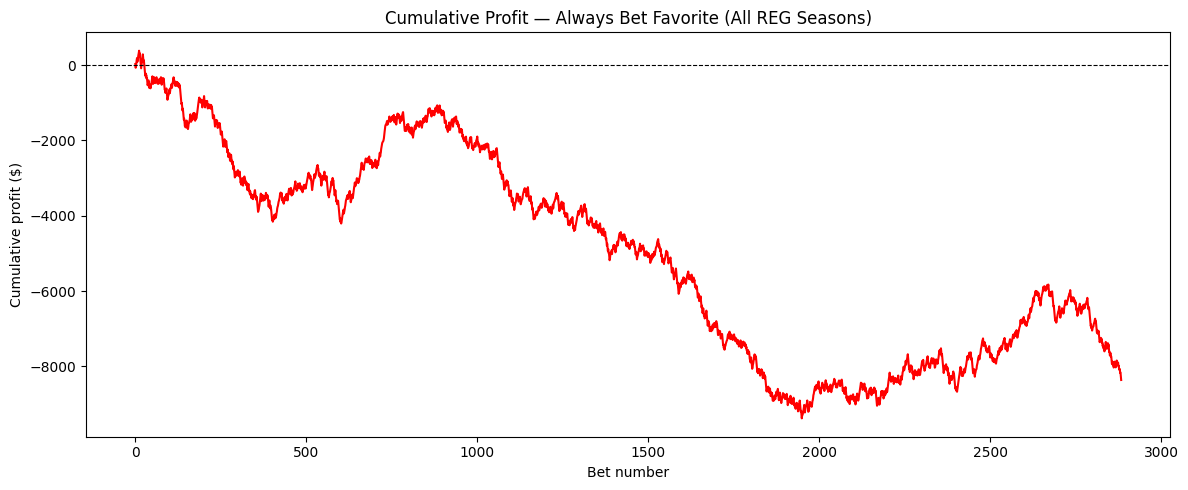

In [54]:
# ── Always bet the favorite baseline ────────────────────────────────────────
sched_base = schedules_raw[[
    'game_id', 'season', 'game_type', 'week',
    'home_team', 'away_team', 'result',
    'home_moneyline', 'away_moneyline'
]].copy()

# Regular season only, drop missing odds, drop ties
sched_base = sched_base[sched_base['game_type'] == 'REG']
sched_base = sched_base.dropna(subset=['result', 'home_moneyline', 'away_moneyline'])
sched_base = sched_base[sched_base['result'] != 0].copy()

# Favorite = team with lower (more negative) moneyline
sched_base['bet_home'] = (sched_base['home_moneyline'] < sched_base['away_moneyline']).astype(int)
sched_base['home_win'] = (sched_base['result'] > 0).astype(int)
sched_base['fav_won']  = (sched_base['bet_home'] == sched_base['home_win']).astype(int)

def fav_profit(row, stake=100):
    odds = row['home_moneyline'] if row['bet_home'] == 1 else row['away_moneyline']
    return american_odds_profit(odds, stake) if row['fav_won'] == 1 else -stake

sched_base['profit'] = sched_base.apply(fav_profit, axis=1)

# ── Overall summary ──────────────────────────────────────────────────────────
total_games   = len(sched_base)
total_wagered = total_games * 100
total_profit  = sched_base['profit'].sum()
overall_acc   = sched_base['fav_won'].mean()
overall_roi   = (total_profit / total_wagered) * 100

print(f"── Always Bet Favorite Baseline (All REG Seasons) ──────────────")
print(f"Total games   : {total_games}")
print(f"Accuracy      : {overall_acc:.4f}")
print(f"Total wagered : ${total_wagered:,.2f}")
print(f"Total profit  : ${total_profit:,.2f}")
print(f"ROI           : {overall_roi:.2f}%")

# ── Per season breakdown ─────────────────────────────────────────────────────
print(f"\n── Per Season ──────────────────────────────────────────────────")
print(f"{'Season':>8} {'Games':>7} {'Accuracy':>10} {'Profit':>12} {'ROI':>8}")
print("-" * 50)

for season in sorted(sched_base['season'].unique()):
    s        = sched_base[sched_base['season'] == season]
    acc      = s['fav_won'].mean()
    profit   = s['profit'].sum()
    wagered  = len(s) * 100
    roi      = (profit / wagered) * 100
    print(f"{season:>8} {len(s):>7} {acc:>10.4f} {profit:>12,.2f} {roi:>7.2f}%")

# ── Cumulative profit plot ───────────────────────────────────────────────────
sched_base['cumulative_profit'] = sched_base['profit'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(sched_base['cumulative_profit'].values,
         color='green' if total_profit > 0 else 'red')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Cumulative Profit — Always Bet Favorite (All REG Seasons)')
plt.xlabel('Bet number')
plt.ylabel('Cumulative profit ($)')
plt.tight_layout()
plt.show()



── Tiered Favorite Accuracy & ROI ──────────────────────────────
Tier                                  Games   Accuracy       Profit      ROI
---------------------------------------------------------------------------
1. Slight     (-101 to -149)            735     0.5497    -1,631.95   -2.22%
2. Moderate   (-150 to -249)           1080     0.6194    -5,635.30   -5.22%
3. Heavy      (-250 to -399)            648     0.7531      -124.14   -0.19%
4. Overwhelming (-400 and below)        421     0.8361      -969.02   -2.30%
---------------------------------------------------------------------------
Overall                                2884     0.6633    -8,360.42   -2.90%


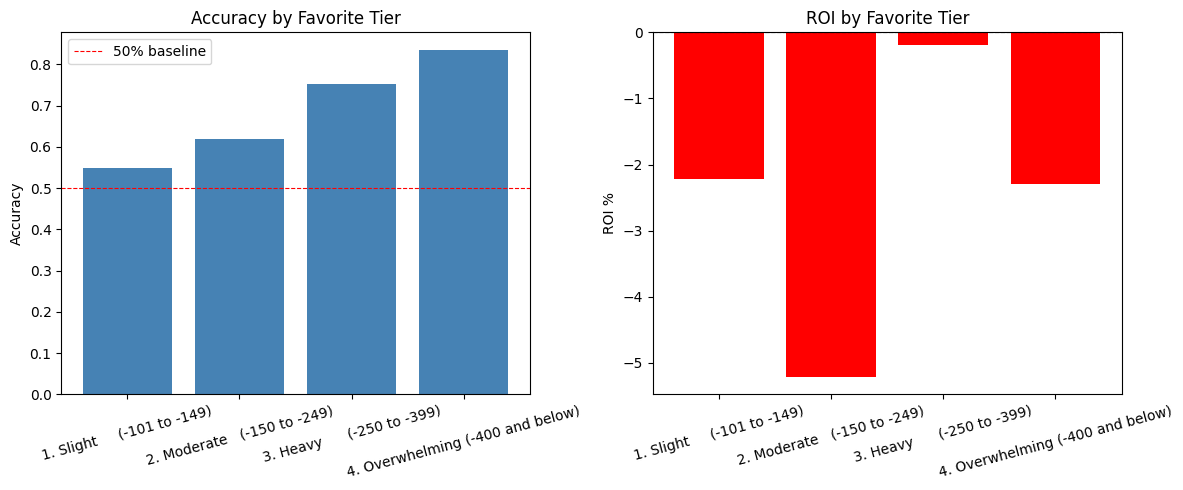

In [55]:
# ── Tiered favorite analysis ─────────────────────────────────────────────────
# Get the actual odds of the favorite for each game
sched_base['fav_odds'] = sched_base.apply(
    lambda row: row['home_moneyline'] if row['bet_home'] == 1 else row['away_moneyline'],
    axis=1
)

# Only look at actual favorites (negative odds)
favs = sched_base[sched_base['fav_odds'] < 0].copy()

# Define tiers
def assign_tier(odds):
    if odds >= -149:
        return '1. Slight     (-101 to -149)'
    elif odds >= -249:
        return '2. Moderate   (-150 to -249)'
    elif odds >= -399:
        return '3. Heavy      (-250 to -399)'
    else:
        return '4. Overwhelming (-400 and below)'

favs['tier'] = favs['fav_odds'].apply(assign_tier)

# ── Summary per tier ─────────────────────────────────────────────────────────
print(f"── Tiered Favorite Accuracy & ROI ──────────────────────────────")
print(f"{'Tier':<35} {'Games':>7} {'Accuracy':>10} {'Profit':>12} {'ROI':>8}")
print("-" * 75)

for tier in sorted(favs['tier'].unique()):
    t        = favs[favs['tier'] == tier]
    acc      = t['fav_won'].mean()
    profit   = t['profit'].sum()
    wagered  = len(t) * 100
    roi      = (profit / wagered) * 100
    print(f"{tier:<35} {len(t):>7} {acc:>10.4f} {profit:>12,.2f} {roi:>7.2f}%")

# Overall
print("-" * 75)
print(f"{'Overall':<35} {len(favs):>7} {favs['fav_won'].mean():>10.4f} "
      f"{favs['profit'].sum():>12,.2f} {(favs['profit'].sum()/(len(favs)*100))*100:>7.2f}%")

# ── ROI bar chart by tier ────────────────────────────────────────────────────
tier_stats = favs.groupby('tier').apply(lambda t: pd.Series({
    'Accuracy': t['fav_won'].mean(),
    'ROI'     : (t['profit'].sum() / (len(t) * 100)) * 100,
    'Games'   : len(t)
})).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(tier_stats['tier'], tier_stats['Accuracy'], color='steelblue')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='50% baseline')
axes[0].set_title('Accuracy by Favorite Tier')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

colors = ['green' if r > 0 else 'red' for r in tier_stats['ROI']]
axes[1].bar(tier_stats['tier'], tier_stats['ROI'], color=colors)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('ROI by Favorite Tier')
axes[1].set_ylabel('ROI %')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
